# Predictive Modeling

Predictive modeling is a core component of machine learning, where algorithms are trained on historical data to forecast future outcomes. By identifying patterns and relationships within the data, these models can make informed predictions about unknown or future data points. Predictive modeling is widely used across various industries, including finance, healthcare, marketing, and beyond, to optimize decision-making, improve efficiency, and drive strategic initiatives. The process involves data preprocessing, feature selection, model training, evaluation, and deployment, with the goal of creating robust and accurate predictive systems.

# Data Collection and Preprocessing

Data collection and preprocessing are foundational steps in building a predictive model. Data collection involves gathering relevant data from various sources, while preprocessing focuses on cleaning, transforming, and organizing the data to make it suitable for modeling. This step is crucial because the quality and relevance of the data directly impact the performance of the predictive model. Common preprocessing tasks include handling missing values, normalizing or scaling features, encoding categorical variables, and splitting the data into training and testing sets.

Below is a sample Python code that demonstrates the data collection and preprocessing steps using a synthetic dataset generated with NumPy.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Data Collection
# Generate synthetic data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y)
y = 2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Step 2: Data Preprocessing
# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Encode categorical variables (if any)
# For simplicity, let's assume there are no categorical variables in this synthetic data

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display the first few rows of the preprocessed data
print("Preprocessed Training Data:")
print(X_train[:5])
print("\nPreprocessed Testing Data:")
print(X_test[:5])

Preprocessed Training Data:
[[-1.5473679   0.37872881  0.03089569 -1.55488568 -0.75189973]
 [-0.70063534 -0.41930746 -1.55164707 -1.34441438  0.07537366]
 [ 1.04135125  1.53844675  0.14927325 -0.02274824 -0.3221057 ]
 [-0.85419091  1.53747908 -1.05745737  1.60025265  1.74570635]
 [-0.31095684  0.58648415  0.66988519 -0.63016713 -1.25910019]]

Preprocessed Testing Data:
[[ 0.05550636 -1.47861257 -0.77538262  0.74322377 -1.50503515]
 [ 0.24022411  1.43356579 -0.37972489 -1.5033965  -1.65685761]
 [ 0.39462326  0.60626423 -0.62808674  1.23802106  1.57950277]
 [-0.20696345  1.65813719  0.23158568 -0.60940267 -0.95603721]
 [ 0.58916395 -0.1073603  -0.29271802  0.54688279  0.17849699]]


1. **Data Collection**: Synthetic data is generated using NumPy. The features (`X`) are random values, and the target (`y`) is a linear combination of some features with added noise.

2. **Data Preprocessing**
    - **Handling Missing Values**: The code checks for and fills any missing values with the mean of the respective column.
    - **Encoding Categorical Variables**: Since the synthetic data does not include categorical variables, this step is skipped.
    - **Train-Test Split**: The data is split into training and testing sets using `train_test_split`.
    - **Feature Scaling**: The features are scaled using `StandardScaler` to ensure that all features contribute equally to the model.

# Feature Selection and Engineering

Feature selection and engineering are critical steps in the predictive modeling process. Feature selection involves identifying the most relevant features that contribute significantly to the model's predictive power, thereby reducing dimensionality and improving model performance. Feature engineering, on the other hand, involves creating new features or transforming existing ones to better capture the underlying patterns in the data. Effective feature selection and engineering can lead to more accurate and interpretable models.

Below is a sample Python code that demonstrates feature selection and engineering using the synthetic dataset generated previously.

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PolynomialFeatures

# Assuming the data has already been collected and preprocessed as shown in the previous step
# Let's use the same synthetic data for this example

# Step 1: Feature Selection
# Use SelectKBest with f_regression to select the top 3 features
selector = SelectKBest(score_func=f_regression, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get the indices of the selected features
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = [data.columns[i] for i in selected_feature_indices]

print("Selected Features:")
print(selected_feature_names)

# Step 2: Feature Engineering
# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_selected)
X_test_poly = poly.transform(X_test_selected)

# Display the first few rows of the engineered features
print("\nEngineered Training Features:")
print(X_train_poly[:5])
print("\nEngineered Testing Features:")
print(X_test_poly[:5])

Selected Features:
['feature_0', 'feature_1', 'feature_2']

Engineered Training Features:
[[-1.54736790e+00  3.78728815e-01  3.08956924e-02  2.39434742e+00
  -5.86032811e-01 -4.78070027e-02  1.43435515e-01  1.17010890e-02
   9.54543809e-04]
 [-7.00635340e-01 -4.19307459e-01 -1.55164707e+00  4.90889880e-01
   2.93781624e-01  1.08713877e+00  1.75818745e-01  6.50617189e-01
   2.40760861e+00]
 [ 1.04135125e+00  1.53844675e+00  1.49273246e-01  1.08441243e+00
   1.60206345e+00  1.55445882e-01  2.36681839e+00  2.29648940e-01
   2.22825021e-02]
 [-8.54190911e-01  1.53747908e+00 -1.05745737e+00  7.29642112e-01
  -1.31330065e+00  9.03270474e-01  2.36384192e+00 -1.62581858e+00
   1.11821609e+00]
 [-3.10956843e-01  5.86484145e-01  6.69885191e-01  9.66941580e-02
  -1.82371258e-01 -2.08305384e-01  3.43963653e-01  3.92877044e-01
   4.48746169e-01]]

Engineered Testing Features:
[[ 0.05550636 -1.47861257 -0.77538262  0.00308096 -0.0820724  -0.04303867
   2.18629512  1.14649049  0.60121821]
 [ 0.240224

1. **Feature Selection**:
    - **SelectKBest**: The `SelectKBest` method with `f_regression` is used to select the top 3 features based on their correlation with the target variable.
    - **Selected Features**: The indices of the selected features are retrieved, and their names are printed.

2. **Feature Engineering**:
    - **Polynomial Features**: The `PolynomialFeatures` transformer is used to create polynomial features up to degree 2. This helps in capturing non-linear relationships between the features and the target.
    - **Engineered Features**: The transformed features are displayed for both the training and testing sets.

# Model Building

Model building is the process of selecting and training a machine learning model on the preprocessed data to make predictions. 

## Linear Regression

Linear Regression is one of the simplest and most interpretable models, making it a good starting point for many predictive modeling tasks. It assumes a linear relationship between the input features and the target variable. The goal is to find the best-fitting line that minimizes the difference between the predicted and actual values.

Below is a sample Python code that demonstrates the process of building and evaluating a Linear Regression model using the preprocessed and engineered data.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the data has already been collected and preprocessed as shown in the previous steps
# Let's use the same synthetic data for this example

# Step 1: Data Collection and Preprocessing
# Generate synthetic data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y)
y = 2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection and Engineering
# Use SelectKBest with f_regression to select the top 3 features
selector = SelectKBest(score_func=f_regression, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_selected)
X_test_poly = poly.transform(X_test_selected)

# Step 3: Model Building
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_poly)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²) Score: {r2}")

Mean Squared Error (MSE): 1.1183008767157092
R-squared (R²) Score: 0.5059535177636778


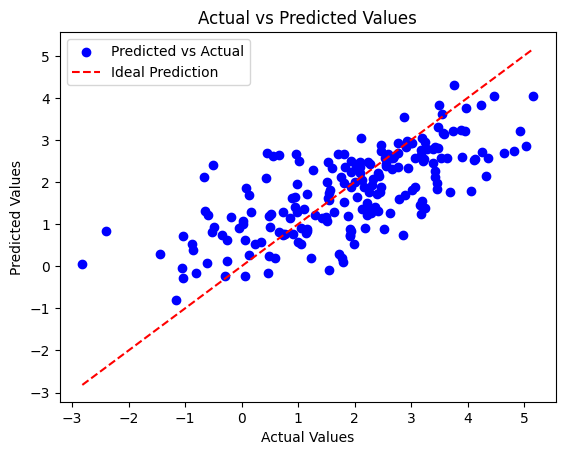

In [4]:
# Optional: Visualize the results
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

1. **Data Collection and Preprocessing**:
    - Synthetic data is generated and preprocessed as described in the previous steps.
    - The data is split into training and testing sets, and features are scaled using `StandardScaler`.

2. **Feature Selection and Engineering**:
    - The `SelectKBest` method with `f_regression` is used to select the top 3 features.
    - Polynomial features up to degree 2 are created using `PolynomialFeatures`.

3. **Model Building**:
    - A `LinearRegression` model is trained on the engineered features.

4. **Model Evaluation**:
    - The model's performance is evaluated using Mean Squared Error (MSE) and R-squared (R²) score.
    - The actual vs. predicted values are visualized for better understanding.


## Logistic Regression

Logistic Regression is a widely used classification algorithm that models the probability of a binary outcome based on one or more input features. Unlike Linear Regression, which is used for regression tasks, Logistic Regression is used for classification tasks. It uses the logistic function (also known as the sigmoid function) to map the linear combination of features to a probability value between 0 and 1. This probability is then used to classify the data into one of the two classes.

Below is a sample Python code that demonstrates the process of building and evaluating a Logistic Regression model using a synthetic binary classification dataset.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Data Collection and Preprocessing
# Generate synthetic binary classification data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y) - Binary classification
y = (2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)) > 0.5

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection
# Use SelectKBest with f_classif to select the top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 3: Model Building
# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_selected, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.855
Confusion Matrix:
[[ 15  23]
 [  6 156]]
Classification Report:
              precision    recall  f1-score   support

       False       0.71      0.39      0.51        38
        True       0.87      0.96      0.91       162

    accuracy                           0.85       200
   macro avg       0.79      0.68      0.71       200
weighted avg       0.84      0.85      0.84       200



1. **Data Collection and Preprocessing**:
    - Synthetic binary classification data is generated. The target variable `y` is a binary outcome based on a linear combination of some features with added noise.
    - The data is preprocessed by handling missing values (if any), splitting into training and testing sets, and scaling the features using `StandardScaler`.

2. **Feature Selection**:
    - The `SelectKBest` method with `f_classif` is used to select the top 3 features based on their ANOVA F-value.

3. **Model Building**:
    - A `LogisticRegression` model is trained on the selected features.

4. Model Evaluation:
    - The model's performance is evaluated using accuracy, confusion matrix, and classification report.

## Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. Each tree in the forest is trained on a random subset of the data and features, and the final prediction is made by aggregating the predictions of all the trees (typically through averaging for regression tasks or majority voting for classification tasks). Random Forest is known for its robustness, versatility, and ability to handle a large number of features.

Below is a sample Python code that demonstrates the process of building and evaluating a Random Forest model using a synthetic binary classification dataset.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Data Collection and Preprocessing
# Generate synthetic binary classification data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y) - Binary classification
y = (2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)) > 0.5

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection
# Use SelectKBest with f_classif to select the top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 3: Model Building
# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_selected, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.815
Confusion Matrix:
[[ 10  28]
 [  9 153]]
Classification Report:
              precision    recall  f1-score   support

       False       0.53      0.26      0.35        38
        True       0.85      0.94      0.89       162

    accuracy                           0.81       200
   macro avg       0.69      0.60      0.62       200
weighted avg       0.78      0.81      0.79       200



1. **Data Collection and Preprocessing**:
    - Synthetic binary classification data is generated. The target variable `y` is a binary outcome based on a linear combination of some features with added noise.
    - The data is preprocessed by handling missing values (if any), splitting into training and testing sets, and scaling the features using `StandardScaler`.

2. **Feature Selection**:
    - The `SelectKBest` method with `f_classif` is used to select the top 3 features based on their ANOVA F-value.

3. **Model Building**:
    - A `RandomForestClassifier` model is trained on the selected features. The number of trees (`n_estimators`) is set to 100, and a random seed is used for reproducibility.

4. **Model Evaluation**:
    - The model's performance is evaluated using accuracy, confusion matrix, and classification report.
## Decision Trees

Decision Trees are a popular and intuitive machine learning algorithm used for both classification and regression tasks. They work by recursively splitting the data into subsets based on the most significant feature at each step, aiming to maximize the homogeneity of the target variable within each subset. Decision Trees are easy to interpret and visualize, making them a good choice for understanding the decision-making process. However, they can be prone to overfitting, especially with complex trees.

Below is a sample Python code that demonstrates the process of building and evaluating a Decision Tree model using a synthetic binary classification dataset.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Data Collection and Preprocessing
# Generate synthetic binary classification data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y) - Binary classification
y = (2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)) > 0.5

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection
# Use SelectKBest with f_classif to select the top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 3: Model Building
# Train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.765
Confusion Matrix:
[[ 13  25]
 [ 22 140]]
Classification Report:
              precision    recall  f1-score   support

       False       0.37      0.34      0.36        38
        True       0.85      0.86      0.86       162

    accuracy                           0.77       200
   macro avg       0.61      0.60      0.61       200
weighted avg       0.76      0.77      0.76       200



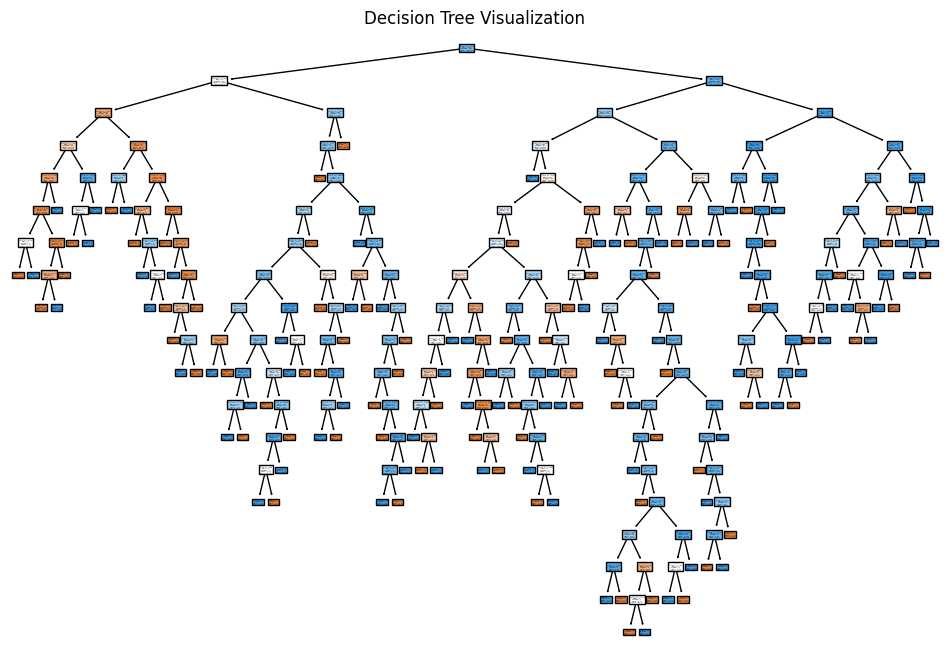

In [4]:
# Optional: Visualize the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=[f'feature_{i}' for i in range(3)], class_names=['Class 0', 'Class 1'])
plt.title('Decision Tree Visualization')
plt.show()

1. **Data Collection and Preprocessing**:
    - Synthetic binary classification data is generated. The target variable `y` is a binary outcome based on a linear combination of some features with added noise.
    - The data is preprocessed by handling missing values (if any), splitting into training and testing sets, and scaling the features using `StandardScaler`.

2. **Feature Selection**:
    - The `SelectKBest` method with `f_classif` is used to select the top 3 features based on their ANOVA F-value.

3. **Model Building**:
    - A `DecisionTreeClassifier` model is trained on the selected features. A random seed is used for reproducibility.

4. **Model Evaluation**:
    - The model's performance is evaluated using accuracy, confusion matrix, and classification report.
    - The confusion matrix is visualized using a heatmap for better understanding.

5. **Visualization**:
    - The Decision Tree is visualized using `plot_tree` from `sklearn.tree` for better interpretation of the decision-making process.

## Support Vector Machines (SVM)

Support Vector Machines (SVM) are a powerful and versatile machine learning algorithm used for both classification and regression tasks. SVM works by finding the hyperplane that best separates the classes in the feature space. For classification, it aims to maximize the margin between the classes, which helps in achieving better generalization. SVM can also handle non-linear boundaries by using kernel functions to transform the feature space.

Below is a sample Python code that demonstrates the process of building and evaluating an SVM model using a synthetic binary classification dataset.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Data Collection and Preprocessing
# Generate synthetic binary classification data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y) - Binary classification
y = (2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)) > 0.5

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection
# Use SelectKBest with f_classif to select the top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 3: Model Building
# Train the SVM model
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_selected, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.85
Confusion Matrix:
[[ 14  24]
 [  6 156]]
Classification Report:
              precision    recall  f1-score   support

       False       0.70      0.37      0.48        38
        True       0.87      0.96      0.91       162

    accuracy                           0.85       200
   macro avg       0.78      0.67      0.70       200
weighted avg       0.83      0.85      0.83       200



1. **Data Collection and Preprocessing**:
    - Synthetic binary classification data is generated. The target variable `y` is a binary outcome based on a linear combination of some features with added noise.
    - The data is preprocessed by handling missing values (if any), splitting into training and testing sets, and scaling the features using `StandardScaler`.

2. **Feature Selection**:
    - The `SelectKBest` method with `f_classif` is used to select the top 3 features based on their ANOVA F-value.

3. **Model Building**:
    - An `SVC` (Support Vector Classifier) model is trained on the selected features. The kernel is set to 'linear' for simplicity, but other kernels like 'rbf' (Radial Basis Function) can be used for non-linear classification.

4. Model Evaluation:
    - The model's performance is evaluated using accuracy, confusion matrix, and classification report.

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple and intuitive machine learning algorithm used for both classification and regression tasks. KNN works by finding the k nearest data points (neighbors) to a given data point in the feature space and making predictions based on the majority class (for classification) or the average value (for regression) of these neighbors. KNN is a non-parametric method, meaning it does not make any assumptions about the underlying data distribution.

Below is a sample Python code that demonstrates the process of building and evaluating a KNN model using a synthetic binary classification dataset.

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Data Collection and Preprocessing
# Generate synthetic binary classification data
np.random.seed(42)
num_samples = 1000
num_features = 5

# Features (X)
X = np.random.rand(num_samples, num_features)

# Target (y) - Binary classification
y = (2 * X[:, 0] + 3 * X[:, 1] - 1.5 * X[:, 2] + np.random.randn(num_samples)) > 0.5

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(num_features)])
data['target'] = y

# Handle missing values (if any)
data.fillna(data.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1), data['target'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Feature Selection
# Use SelectKBest with f_classif to select the top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Step 3: Model Building
# Train the KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_selected, y_train)

# Step 4: Model Evaluation
# Make predictions on the test set
y_pred = model.predict(X_test_selected)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.84
Confusion Matrix:
[[ 16  22]
 [ 10 152]]
Classification Report:
              precision    recall  f1-score   support

       False       0.62      0.42      0.50        38
        True       0.87      0.94      0.90       162

    accuracy                           0.84       200
   macro avg       0.74      0.68      0.70       200
weighted avg       0.82      0.84      0.83       200



1. **Data Collection and Preprocessing**:
    - Synthetic binary classification data is generated. The target variable `y` is a binary outcome based on a linear combination of some features with added noise.
    - The data is preprocessed by handling missing values (if any), splitting into training and testing sets, and scaling the features using `StandardScaler`.

2. **Feature Selection**:
    - The `SelectKBest` method with `f_classif` is used to select the top 3 features based on their ANOVA F-value.

3. **Model Building**:
    - A `KNeighborsClassifier` model is trained on the selected features. The number of neighbors (`n_neighbors`) is set to 5.

4. **Model Evaluation**:
    - The model's performance is evaluated using accuracy, confusion matrix, and classification report.